# Carregando todos os grafos e extraindo suas propriedades

In [1]:
from pathlib import Path
import os
import pickle
import networkx as nx
import pandas as pd
from tqdm.notebook import tqdm
import numpy as np

In [2]:
GRAPH_DIR = "/exp_local/kenzosaki/data/iptc/graphs"

In [3]:
# carregando grafos e extraindo infos
graph_info = []
n_graphs = len(os.listdir(GRAPH_DIR))
for graph_file in tqdm(Path(GRAPH_DIR).glob("*.pkl"), desc="Processing graphs", total=n_graphs):
    with open(graph_file, "rb") as f:
        graph = pickle.load(f)
    # tema 
    graph_theme = graph_file.stem.split("_")[0]
    # propriedades de interesse
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()
    density = nx.density(graph)
    avg_degree = sum(dict(graph.degree()).values()) / num_nodes
    max_degree = max(dict(graph.degree()).values())

    # proporção das arestas que liga componentes
    comp_bridges = sum([1 if edge[2]["edge_type"] == "component_bridge" else 0 for edge in graph.edges(data=True)])
    comp_bridge_pct = comp_bridges / num_edges

    clustering_coef = nx.average_clustering(graph)
    assortativity = nx.degree_assortativity_coefficient(graph)

    # propriedades de caminhos
    shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(graph))
    all_path_lengths = []
    for spl in shortest_path_lengths.values():
        all_path_lengths.extend(list(spl.values())) 
    avg_shortest_path_length = np.mean(all_path_lengths)
    max_shortest_path_length = max(
        max(spl.values()) for spl in shortest_path_lengths.values()
    )

    # armazenando infos
    graph_info.append({
        "theme": graph_theme,
        "num_nodes": num_nodes,
        "num_edges": num_edges,
        "component_bridge_pct": comp_bridge_pct,
        "density": density,
        "avg_degree": avg_degree,
        "max_degree": max_degree,
        "clustering_coef": clustering_coef,
        "assortativity": assortativity,
        "avg_shortest_path_length": avg_shortest_path_length,
        "max_shortest_path_length": max_shortest_path_length
    })


Processing graphs:   0%|          | 0/15 [00:00<?, ?it/s]

In [4]:
graph_info_df = pd.DataFrame(graph_info)
pd.options.display.float_format = '{:.3f}'.format
graph_info_df.sort_values("component_bridge_pct", ascending=False)

,theme,num_nodes,num_edges,component_bridge_pct,density,avg_degree,max_degree,clustering_coef,assortativity,avg_shortest_path_length,max_shortest_path_length
2,society,4931,5246,0.599,0.000,2.128,106,0.020,-0.105,2.514,11
5,transport,5327,6507,0.392,0.000,2.443,34,0.040,0.011,2.497,14
11,weather,7959,10912,0.370,0.000,2.742,56,0.048,0.390,2.436,14
8,conflict,7376,11335,0.334,0.000,3.073,49,0.060,0.093,5.757,25
9,cybersecurity,9975,15937,0.279,0.000,3.195,43,0.063,0.326,20.611,67
0,disaster,8674,11991,0.213,0.000,2.765,25,0.074,0.174,4.794,27
14,science,9938,15281,0.185,0.000,3.075,62,0.060,0.541,4.509,27
7,environment,9973,16027,0.183,0.000,3.214,31,0.071,0.256,12.531,51
6,health,9874,21911,0.176,0.000,4.438,112,0.098,0.563,6.699,24
1,economy,9995,16981,0.137,0.000,3.398,46,0.078,0.300,6.716,29


In [5]:
graph_info_df["component_bridge_pct"].describe()

count   15.000
mean     0.231
std      0.140
min      0.094
25%      0.135
50%      0.183
75%      0.306
max      0.599
Name: component_bridge_pct, dtype: float64

In [6]:
graph_info_df.to_csv("../data/graph_info_summary.csv", index=False, decimal=",")

# Verificando distribuição de graus

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
def get_all_degrees(G: nx.Graph):
    return [d for n, d in G.degree()]

In [9]:
n_graphs = len(os.listdir(GRAPH_DIR))
degrees_map = {}
for graph_file in tqdm(Path(GRAPH_DIR).glob("*.pkl"), desc="Obtaining degrees", total=n_graphs):
    with open(graph_file, "rb") as f:
        graph = pickle.load(f)
    graph_theme = graph_file.stem.split("_")[0]
    degrees_map[graph_theme] = get_all_degrees(graph)

Obtaining degrees:   0%|          | 0/15 [00:00<?, ?it/s]

In [10]:
degree_df = pd.DataFrame(dict([(k.capitalize(), pd.Series(v)) for k, v in degrees_map.items()]))

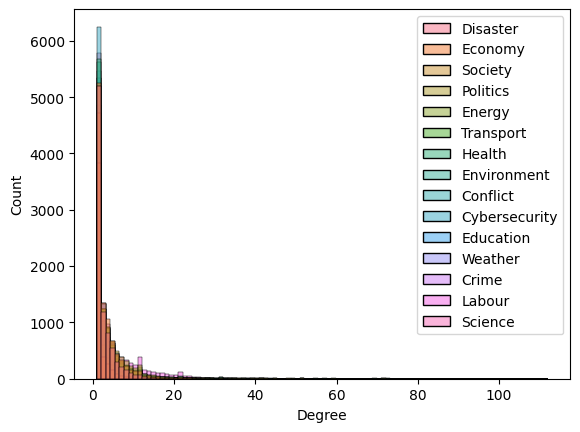

In [11]:
sns.histplot(data=degree_df, bins=100)
plt.xlabel("Degree")
plt.savefig("../data/degree_dist.pdf", bbox_inches="tight")